In [3]:
import os

In [4]:
base_dir = 'C:/Users/Acer/OneDrive/Desktop/lungCancer/ctscan_images/'
print("Contents of the base directory:")
print(os.listdir(base_dir))

print("\nContents of train directory:")
print(os.listdir(f'{base_dir}/train'))

print("\nContents of validation directory:")
print(os.listdir(f'{base_dir}/test'))

Contents of the base directory:
['test', 'train']

Contents of train directory:
['large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal']

Contents of validation directory:
['large.cell.carcinoma', 'normal']


In [5]:
import os
train_dr = os.path.join(base_dir, 'train')
test_dr = os.path.join(base_dir, 'test')

train_lung_cancer = os.path.join(train_dr, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa')
train_normal = os.path.join(train_dr, 'normal')

test_lung_cancer = os.path.join(test_dr, 'large.cell.carcinoma')
test_normal = os.path.join(test_dr, 'noraml')

In [6]:
print('total train lung cancer images', len(os.listdir(train_lung_cancer)))
print('total train normal images', len(os.listdir(train_normal)))
print('total test lung cancer images', len(os.listdir(test_lung_cancer)))
print('total test noraml images', len(os.listdir(train_normal)))

total train lung cancer images 136
total train normal images 151
total test lung cancer images 51
total test noraml images 151


In [7]:
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt



In [8]:
nrows = 4
ncols = 4
pic_index = 0

In [9]:
train_lung_cancer_fnames = os.listdir(train_lung_cancer)
train_normal_fnames=os.listdir(train_normal)

print(train_lung_cancer_fnames[:10])
print(train_normal_fnames[:10])

['000002.png', '000003 (3).png', '000003 (4).png', '000009 (3).png', '000009 (4).png', '000010.png', '000015.png', '000016 (3).png', '000016 (4).png', '000017.png']
['003828_02_01_174.png', '004007_01_01_519.png', '004162_01_01_150.png', '10 (2) - Copy.png', '10 (2).png', '10 - Copy (2) - Copy.png', '10 - Copy (2).png', '10 - Copy (3).png', '10 - Copy - Copy.png', '10 - Copy.png']


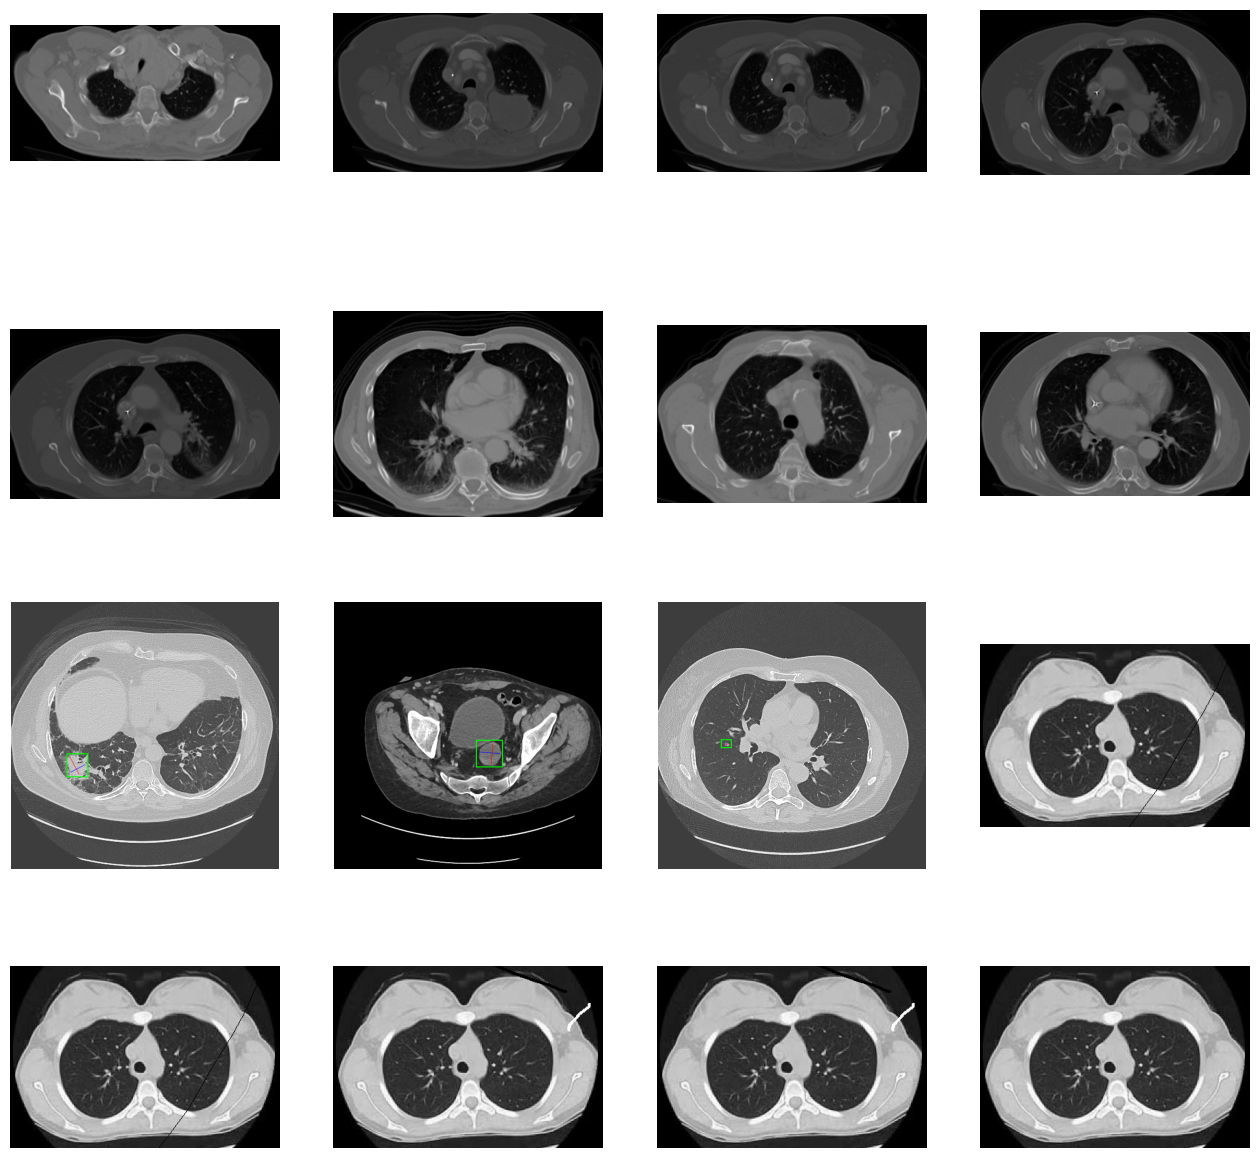

In [10]:
fig = plt.gcf()
fig.set_size_inches(ncols*4, nrows*4)

pic_index+=8

next_cat_pix = [os.path.join(train_lung_cancer, fname) 
                for fname in  train_lung_cancer_fnames[ pic_index-8:pic_index] 
               ]

next_dog_pix = [os.path.join(train_normal, fname) 
                for fname in train_normal_fnames[ pic_index-8:pic_index]
               ]

for i, img_path in enumerate(next_cat_pix+next_dog_pix):
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off') 

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()

In [11]:
import tensorflow as tf
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 18496)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       9,470,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.optimizers import RMSprop

model.compile(optimizer=RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics = ['accuracy'])

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator( rescale = 1.0/255. )
test_datagen  = ImageDataGenerator( rescale = 1.0/255. )


train_generator = train_datagen.flow_from_directory(train_dr,
                                                    batch_size=20,
                                                    class_mode='binary',
                                                    target_size=(150, 150))     

test_generator =  test_datagen.flow_from_directory(test_dr,
                                                         batch_size=20,
                                                         class_mode  = 'binary',
                                                         target_size = (150, 150))

Found 287 images belonging to 2 classes.
Found 105 images belonging to 2 classes.


In [15]:
history = model.fit(
                    train_generator,
                    epochs=15,
                    validation_data=test_generator,
                    verbose=2
                    )

C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
15/15 - 9s - 585ms/step - accuracy: 0.5575 - loss: 1.0924 - val_accuracy: 0.6000 - val_loss: 0.5697
Epoch 2/15
15/15 - 5s - 360ms/step - accuracy: 0.8223 - loss: 0.4411 - val_accuracy: 0.7143 - val_loss: 0.6545
Epoch 3/15
15/15 - 5s - 355ms/step - accuracy: 0.8990 - loss: 0.3486 - val_accuracy: 0.9524 - val_loss: 0.1784
Epoch 4/15
15/15 - 5s - 355ms/step - accuracy: 0.9547 - loss: 0.1419 - val_accuracy: 0.9429 - val_loss: 0.1580
Epoch 5/15
15/15 - 10s - 689ms/step - accuracy: 0.9512 - loss: 0.1652 - val_accuracy: 0.8952 - val_loss: 0.2687
Epoch 6/15
15/15 - 5s - 348ms/step - accuracy: 1.0000 - loss: 0.0188 - val_accuracy: 0.9143 - val_loss: 0.2293
Epoch 7/15
15/15 - 5s - 348ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.9238 - val_loss: 0.3323
Epoch 8/15
15/15 - 5s - 349ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9238 - val_loss: 0.2791
Epoch 9/15
15/15 - 10s - 694ms/step - accuracy: 0.9512 - loss: 0.3269 - val_accuracy: 0.8571 - val_loss: 0.4025

In [16]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
from google.colab import files

ModuleNotFoundError: No module named 'google.colab'

In [17]:
uploaded=files.upload()

for fn in uploaded.keys():
 
  # predicting images
  path='/content/' + fn
  img=load_img(path, target_size=(150, 150))
  
  x=img_to_array(img)
  x /= 255
  x=np.expand_dims(x, axis=0)
  images = np.vstack([x])
  
  classes = model.predict(images, batch_size=10)
  
  print(classes[0])
  
  if classes[0][0]>0.5:
    print(fn + " is a normal case")
  else:
    print(fn + " is a lung cancer case")

NameError: name 'files' is not defined

In [18]:
import pandas as pd
model_loss=pd.DataFrame(history.history)
model_loss

,accuracy,loss,val_accuracy,val_loss
0,0.557491,1.092373,0.600000,0.569724
1,0.822300,0.441116,0.714286,0.654482
2,0.898955,0.348626,0.952381,0.178414
3,0.954704,0.141919,0.942857,0.157961
4,0.951219,0.165241,0.895238,0.268653
5,1.000000,0.018773,0.914286,0.229275
6,1.000000,0.007772,0.923810,0.332348
7,1.000000,0.002519,0.923810,0.279067
8,0.951219,0.326878,0.857143,0.402549
9,1.000000,0.032112,0.904762,0.321708


<Axes: >

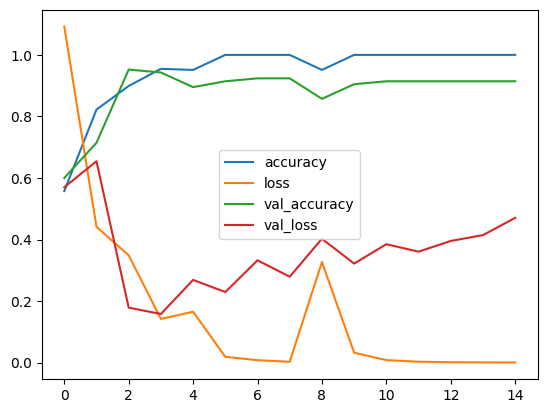

In [19]:
model_loss.plot()

In [27]:
import matplotlib.pyplot as plt
def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history.history['accuracy']
    val_acc=history.history['val_accuracy']
    loss=history.history['loss']
    val_loss=history.history['val_loss']

    epochs = range(len(acc))

    plt.plot(epochs, acc, 'r', label ='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='validation accuracy')
    plt.title('Training and validation loss')
    plt.figure()

    plt.plot(epochs, acc, 'r', label ='Training Loss')
    plt.plot(epochs, val_acc, 'b', label='validation Loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

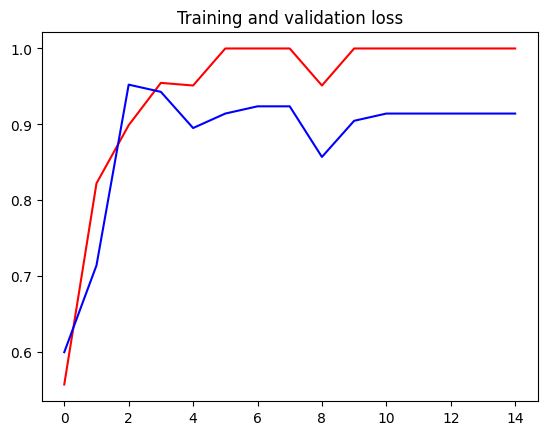

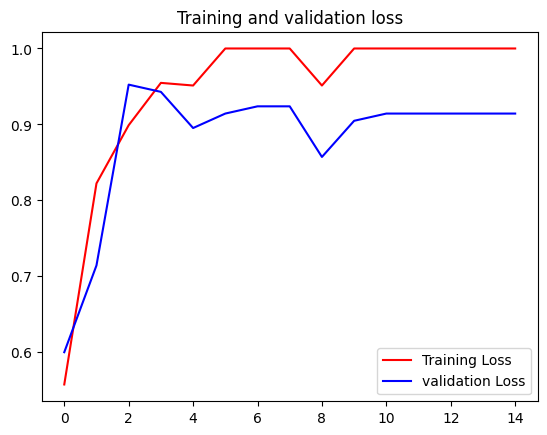

In [28]:
plot_loss_acc(history)

In [31]:
from keras.models import load_model
model.save("Lungcancer_model_cnn.h5")